# Week 3 - Maryi Tatiana Palacios Giraldo

In [24]:
pip install gymnasium matplotlib numpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
pip install gymnasium[toy-text]

Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: gymnasium[toy-text] in c:\users\thati\appdata\local\programs\python\python39\lib\site-packages (1.1.1)
   ---------------------------------------- 0.0/10.6 MB ? eta -:--:--
   - -------------------------------------- 0.5/10.6 MB 2.8 MB/s eta 0:00:04
   --- ------------------------------------ 1.0/10.6 MB 2.5 MB/s eta 0:00:04
   ----- ---------------------------------- 1.6/10.6 MB 2.8 MB/s eta 0:00:04
   -------- ------------------------------- 2.4/10.6 MB 2.8 MB/s eta 0:00:03
   ---------- ----------------------------- 2.9/10.6 MB 2.8 MB/s eta 0:00:03
   ------------ --------------------------- 3.4/10.6 MB 2.8 MB/s eta 0:00:03
   -------------- ------------------------- 3.9/10.6 MB 2.8 MB/s eta 0:00:03
   ---------------- ----------------------- 4.5/10.6 MB 2.8 MB/s eta 0:00:03
   ------------------- -------------------- 5.2/10.6 MB 2.8 MB/s eta 0:00:02
   --------------------- -------------


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [26]:
import gymnasium as gym
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt

In [27]:
env = gym.make("Blackjack-v1")

In [29]:
Q = defaultdict(lambda: np.zeros(env.action_space.n))
returns = defaultdict(list)

# ε-soft

In [30]:
def epsilon_greedy_policy(Q, state, epsilon):
    nA = len(Q[state])
    probs = np.ones(nA) * (epsilon / nA)
    best_action = np.argmax(Q[state])
    probs[best_action] += (1.0 - epsilon)
    return probs

In [31]:
def generate_episode(env, Q, epsilon):
    episode = []
    state, _ = env.reset()
    
    while True:
        probs = epsilon_greedy_policy(Q, state, epsilon)
        action = np.random.choice(np.arange(len(probs)), p=probs)
        
        next_state, reward, terminated, truncated, _ = env.step(action)
        
        episode.append((state, action, reward))
        
        if terminated or truncated:
            break
        
        state = next_state
    
    return episode

# Monte Carlo Control (FIRST-VISIT)

In [32]:
def mc_control(env, num_episodes, gamma=1.0, epsilon=0.1):
    Q = defaultdict(lambda: np.zeros(env.action_space.n))
    returns = defaultdict(list)
    
    for i in range(num_episodes):
        episode = generate_episode(env, Q, epsilon)
        
        G = 0
        visited = set()
        
        for t in reversed(range(len(episode))):
            state, action, reward = episode[t]
            G = gamma * G + reward
            
            if (state, action) not in visited:
                visited.add((state, action))
                
                returns[(state, action)].append(G)
                Q[state][action] = np.mean(returns[(state, action)])
    
    return Q

In [34]:
Q = mc_control(env, num_episodes=10000, epsilon=0.1)

In [35]:
print("Sample Q values:")
for i, (state, values) in enumerate(Q.items()):
    print(state, values)
    if i > 10:
        break

Sample Q values:
(13, 9, 0) [-0.625      -0.42424242]
(14, 9, 0) [-0.6091954 -1.       ]
(15, 2, 0) [-0.42857143 -0.4       ]
(13, 2, 0) [-0.25       -0.30666667]
(13, 7, 0) [-0.45454545 -1.        ]
(16, 4, 1) [-0.5  0.8]
(11, 5, 0) [0.07692308 0.34482759]
(17, 5, 0) [-0.08955224 -1.        ]
(13, 10, 0) [-0.56296296 -0.57142857]
(15, 10, 0) [-0.66666667 -1.        ]
(9, 5, 0) [-0.17647059 -1.        ]
(12, 10, 0) [-0.51724138 -0.42253521]


In [36]:
def get_policy(Q):
    policy = {}
    for state in Q:
        policy[state] = np.argmax(Q[state])
    return policy

policy = get_policy(Q)

In [37]:
print("Sample policy:")
for i, (state, action) in enumerate(policy.items()):
    print(state, action)
    if i > 10:
        break

Sample policy:
(13, 9, 0) 1
(14, 9, 0) 0
(15, 2, 0) 1
(13, 2, 0) 0
(13, 7, 0) 0
(16, 4, 1) 1
(11, 5, 0) 1
(17, 5, 0) 0
(13, 10, 0) 0
(15, 10, 0) 0
(9, 5, 0) 0
(12, 10, 0) 1


In [38]:
from mpl_toolkits.mplot3d import Axes3D

def plot_value_function(Q, usable_ace=True):
    x_range = np.arange(12, 22)
    y_range = np.arange(1, 11)
    X, Y = np.meshgrid(x_range, y_range)
    
    Z = np.zeros_like(X, dtype=float)
    
    for i in range(len(x_range)):
        for j in range(len(y_range)):
            state = (x_range[i], y_range[j], usable_ace)
            if state in Q:
                Z[j, i] = np.max(Q[state])
    
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(X, Y, Z)
    
    ax.set_xlabel('Player Sum')
    ax.set_ylabel('Dealer Showing')
    ax.set_zlabel('Value')
    
    title = "Usable Ace" if usable_ace else "No Usable Ace"
    ax.set_title(title)
    
    plt.show()

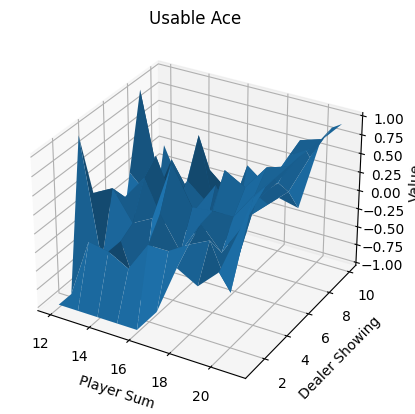

In [41]:
plot_value_function(Q, usable_ace=True)


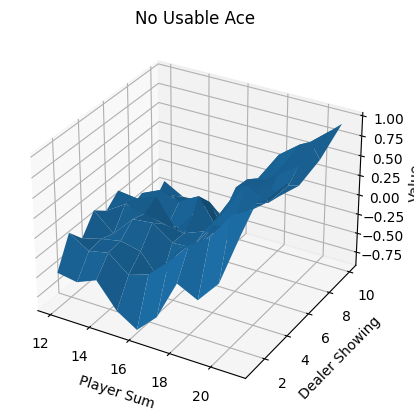

In [42]:
plot_value_function(Q, usable_ace=False)

The value function with a usable ace shows higher values across a wider range of player sums, reflecting the increased flexibility provided by the ace. Since the ace can be counted as 1 or 11, the agent can take more aggressive actions with lower risk of busting, resulting in higher expected returns. This behavior is consistent with Monte Carlo estimates derived from complete episodes (Sutton & Barto, Chapter 5).

In [44]:
def mc_control(env, num_episodes, gamma=1.0, epsilon=0.1):
    Q = defaultdict(lambda: np.zeros(env.action_space.n))
    returns = defaultdict(list)
    
    episode_rewards = [] 
    
    for i in range(num_episodes):
        episode = generate_episode(env, Q, epsilon)
        
        G = 0
        visited = set()
        
        total_reward = sum([x[2] for x in episode]) 
        episode_rewards.append(total_reward)
        
        for t in reversed(range(len(episode))):
            state, action, reward = episode[t]
            G = gamma * G + reward
            
            if (state, action) not in visited:
                visited.add((state, action))
                
                returns[(state, action)].append(G)
                Q[state][action] = np.mean(returns[(state, action)])
    
    return Q, episode_rewards

In [45]:
Q, rewards = mc_control(env, num_episodes=500000, epsilon=0.1)

In [46]:
def plot_learning_curve(rewards, window=1000):
    smoothed = np.convolve(rewards, np.ones(window)/window, mode='valid')
    
    plt.plot(smoothed)
    plt.xlabel("Episodes")
    plt.ylabel("Average Reward")
    plt.title("Learning Curve (Smoothed)")
    plt.show()

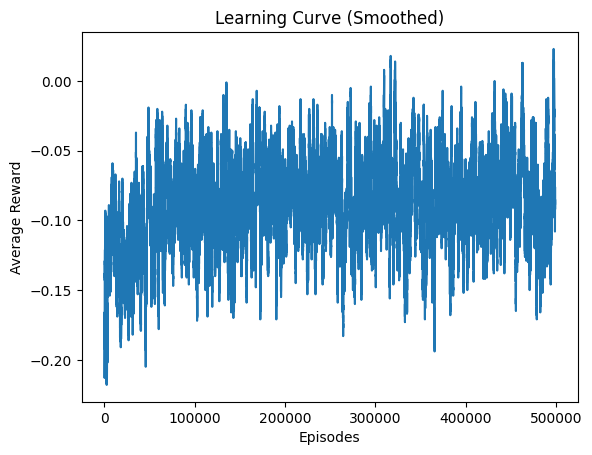

In [47]:
plot_learning_curve(rewards)

From 0 to 100,000 episodes, the agent is collecting sufficient samples to estimate the action-value function 
𝑄(𝑠,𝑎)Q(s,a) for frequently visited states. During this phase, there is clear learning as the agent improves its estimates based on observed returns from complete episodes.

From 100,000 to 500,000 episodes, the agent enters a near-stationary regime where the policy has largely stabilized. The updates, based on full-episode returns, continue to fluctuate around a mean due to the high variance inherent in Monte Carlo methods. Since the policy is already close to optimal, further improvements are limited, and the agent primarily refines its estimates rather than discovering significantly better strategies.

In [48]:
def get_policy(Q):
    policy = {}
    for state in Q:
        policy[state] = np.argmax(Q[state])
    return policy

policy = get_policy(Q)

In [49]:
Q1, rewards1 = mc_control(env, num_episodes=200000, epsilon=0.1)
Q2, rewards2 = mc_control(env, num_episodes=200000, epsilon=0.01)

In [50]:
def plot_multiple_learning_curves(rewards_list, labels, window=1000):
    for rewards, label in zip(rewards_list, labels):
        smoothed = np.convolve(rewards, np.ones(window)/window, mode='valid')
        plt.plot(smoothed, label=label)
    
    plt.xlabel("Episodes")
    plt.ylabel("Average Reward")
    plt.title("Learning Curve Comparison")
    plt.legend()
    plt.show()

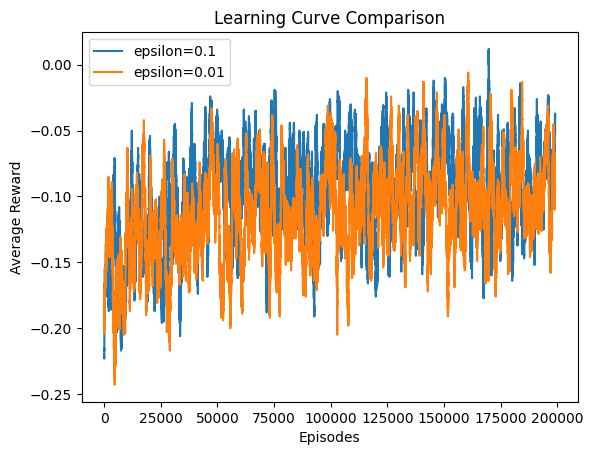

In [51]:
plot_multiple_learning_curves(
    [rewards1, rewards2],
    ["epsilon=0.1", "epsilon=0.01"]
)

The comparison between ε = 0.1 and ε = 0.01 highlights the exploration–exploitation tradeoff in Monte Carlo control. With ε = 0.1, the agent explores more frequently, which allows it to discover higher-value state-action pairs, reflected in occasional peaks in performance. However, this increased exploration also leads to higher variance, as the agent continues to take suboptimal actions with non-negligible probability.

In contrast, ε = 0.01 results in a more stable learning curve with lower variance. The agent exploits its current policy more consistently, leading to smoother performance over time. However, the reduced exploration limits its ability to discover potentially better strategies, which may explain the slightly lower peak performance compared to ε = 0.1.

This behavior is consistent with the ε-soft policy framework described in Chapter 5 of Sutton & Barto, where higher ε promotes exploration at the cost of stability, while lower ε favors exploitation but risks converging prematurely to suboptimal policies.